# Predicting HPC output from region features (beyond the afferent profile)

Follow-up to `hpc_io_transformation.ipynb` **Module 2**. There, a reduced-rank regression predicting
each region's **efferent** profile (HPC → region) from its **afferent** profile (region → HPC) had
**leave-one-out $R^2 \approx 0$** — a region's hippocampal *input* does not predict its hippocampal
*output*, and removing outliers didn't rescue it. The failure was pervasive: **no global rule maps
afferent → efferent**.

That raises the real question: is HPC output *unpredictable*, or just not predictable **from the
afferent profile**? Maybe what the hippocampus sends a region is determined by **what kind of region it
is** — its anatomy or its broader connectivity — rather than by what it sends back. This notebook tests
two additional feature sets:

1. **Major division** (anatomical class: CTX, TH, HY, CNU, MB, …) as a covariate.
2. A **low-dimensional embedding of the region's whole-brain connectivity fingerprint** (its
   connections to the *rest* of the brain, HPC excluded) — its "connectional identity."

**Design (held constant for a fair comparison):** the 72 bidirectional regions (so afferent, efferent,
and division are all defined); **leave-one-out $R^2$ vs the mean-efferent baseline**, the same metric as
Module 2; a **ridge** estimator (LOO-CV–tuned) throughout, which regularizes better than plain OLS/RRR
at $n = 72$ and handles mixed continuous + categorical features. Whole-brain fingerprints **exclude the
7 HPC columns/rows** so no efferent information leaks into the predictors.

## Infrastructure (reproduces the Module 2 setup, self-contained)

Load the afferent/efferent profiles for the 72 shared regions (ordinal → `log_weight_transform` →
L2-normalize each row), rebuild the Module 2 RRR helpers, and define the ridge leave-one-out evaluator
used for every feature set below. We also re-establish the **afferent-only baseline** under both RRR
(matches Module 2) and ridge.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler

from helpers import get_feature_vectors_shared_hpc, log_weight_transform

HPC = ['DG', 'CA3', 'CA2', 'CA1v', 'CA1d', 'SUBv', 'SUBd']
SEED = 0
OUTDIR = Path('../output/hpc_io_transformation'); OUTDIR.mkdir(parents=True, exist_ok=True)

# --- profiles for the 72 shared regions (region x 7 subfields), L2-normalized rows ---
df_to, df_from = get_feature_vectors_shared_hpc()
regions = list(df_to.columns)
def to_profiles(df):
    X = log_weight_transform(df.values).T
    return X / np.linalg.norm(X, axis=1, keepdims=True)
A = to_profiles(df_to)      # afferent (region -> HPC)
E = to_profiles(df_from)    # efferent (HPC -> region)  <- prediction TARGET
n = len(regions)

# --- Module 2 RRR helpers (for the baseline, to tie back to that notebook) ---
def ols_B(Ain, Ein): return np.linalg.pinv(Ain) @ Ein
def rrr_B(Ain, Ein, k):
    B = ols_B(Ain, Ein); Vt = np.linalg.svd(Ain @ B, full_matrices=False)[2]
    return B @ Vt[:k].T @ Vt[:k]
def rrr_loo_r2(Ain, Ein, k):
    err = tot = 0.0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        err += np.sum((Ein[i] - Ain[i] @ rrr_B(Ain[m], Ein[m], k))**2)
        tot += np.sum((Ein[i] - Ein[m].mean(0))**2)
    return 1 - err / tot

# --- ridge leave-one-out R^2 (vs mean-efferent baseline). Standardizes features within each
#     training fold and tunes the ridge penalty by inner LOO-CV (RidgeCV). Used for all feature sets. ---
ALPHAS = np.logspace(-2, 3, 12)
def ridge_loo_r2(X, Y=E, return_pred=False):
    X = np.asarray(X, float); pred = np.zeros_like(Y); tot = 0.0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        sc = StandardScaler().fit(X[m])
        r = RidgeCV(alphas=ALPHAS).fit(sc.transform(X[m]), Y[m])
        pred[i] = r.predict(sc.transform(X[i:i+1]))
        tot += np.sum((Y[i] - Y[m].mean(0))**2)
    r2 = 1 - np.sum((Y - pred)**2) / tot
    return (r2, pred) if return_pred else r2

def participation_ratio(X):
    s2 = np.linalg.svd(X - X.mean(0), compute_uv=False)**2
    return (s2.sum()**2) / (s2**2).sum()

print(f'{n} shared regions | afferent PR={participation_ratio(A):.2f}  efferent PR={participation_ratio(E):.2f}')
print('\nAfferent-only baseline (predict efferent from afferent):')
print(f'  RRR   LOO R2 (rank 1, matches Module 2) = {rrr_loo_r2(A, E, 1):+.3f}')
print(f'  ridge LOO R2                            = {ridge_loo_r2(A):+.3f}')
print('  => essentially no predictive power from the afferent profile (ridge just regularizes it to ~0).')
results = {'afferent': ridge_loo_r2(A)}

72 shared regions | afferent PR=4.38  efferent PR=2.43

Afferent-only baseline (predict efferent from afferent):
  RRR   LOO R2 (rank 1, matches Module 2) = -0.003
  ridge LOO R2                            = +0.034
  => essentially no predictive power from the afferent profile (ridge just regularizes it to ~0).


## 1. Major division as a covariate

Does a region's coarse **anatomical class** predict what HPC sends it? We one-hot encode `major_division`
and evaluate three feature sets: division alone, afferent alone (baseline), and afferent + division.

In [2]:
# major_division for the 72 regions (matched from the symmetry-score table)
meta = pd.read_csv('../output/brain_regions_symmetry_score.csv').set_index('brain_region').reindex(regions)
div_dummies = pd.get_dummies(meta['major_division'])
DIV = div_dummies.values.astype(float)
print('division counts:', dict(meta['major_division'].value_counts()))

results['division'] = ridge_loo_r2(DIV)
results['afferent+division'] = ridge_loo_r2(np.hstack([A, DIV]))
print(f"\nLOO R2 predicting efferent profile:")
print(f"  division only       : {results['division']:+.3f}")
print(f"  afferent only       : {results['afferent']:+.3f}")
print(f"  afferent + division : {results['afferent+division']:+.3f}")
print("\n=> coarse anatomical class (5 divisions) barely helps: it does not, on its own, predict the")
print("   efferent profile, and adds little to the afferent baseline. HPC output is not organized by")
print("   this coarse a label.")

division counts: {'CTX': np.int64(24), 'CNU': np.int64(21), 'HY': np.int64(18), 'TH': np.int64(8), 'MB': np.int64(1)}



LOO R2 predicting efferent profile:
  division only       : -0.008
  afferent only       : +0.034
  afferent + division : +0.045

=> coarse anatomical class (5 divisions) barely helps: it does not, on its own, predict the
   efferent profile, and adds little to the afferent baseline. HPC output is not organized by
   this coarse a label.


## 2. Whole-brain connectivity fingerprint (embedded)

A finer notion of "what kind of region": its **connections to the rest of the brain** — its connectional
identity. For each region we take its outgoing and incoming connections to all **non-HPC** regions
(HPC excluded, so no efferent information leaks in), log-weight them, and reduce to a low-dimensional
**PCA embedding**. We sweep the embedding dimension (2, 5, 10) and evaluate the fingerprint alone and
combined with the afferent profile.

In [3]:
# Whole-brain fingerprint from the average connectome; HPC columns/rows removed to prevent leakage.
conn = pd.read_csv('../data/average_connectome_data.csv', header=0, index_col=0).fillna(0.0)
non_hpc = [r for r in conn.index if r not in HPC]
# round the connectome's lone non-integer entry(s) so log_weight_transform accepts them
lw = lambda M: log_weight_transform(np.round(M).astype(int))
out_fp = lw(conn.loc[regions, non_hpc].values)     # region -> other regions (outgoing)
in_fp  = lw(conn.loc[non_hpc, regions].values.T)   # other regions -> region (incoming)
WB = np.hstack([out_fp, in_fp])                    # 72 x (2 * n_non_hpc), HPC-free connectional identity
print(f'whole-brain fingerprint: {WB.shape}  (in+out, HPC excluded)')

def pca_embed(X, k):
    Xc = X - X.mean(0); Vt = np.linalg.svd(Xc, full_matrices=False)[2]
    return Xc @ Vt[:k].T

print('\nLOO R2 predicting efferent profile, sweeping embedding dimension k:')
wb_scores = {}
for k in (2, 5, 10):
    WBk = pca_embed(WB, k)
    r_wb   = ridge_loo_r2(WBk)
    r_both = ridge_loo_r2(np.hstack([A, WBk]))
    wb_scores[k] = (r_wb, r_both)
    print(f'  k={k:2d}:  whole-brain only = {r_wb:+.3f}    afferent + whole-brain = {r_both:+.3f}')

best_k = max(wb_scores, key=lambda k: wb_scores[k][0])
results['whole-brain (best k)'] = wb_scores[best_k][0]
results['afferent+whole-brain (best k)'] = max(v[1] for v in wb_scores.values())
print(f'\n=> the whole-brain fingerprint predicts HPC output MUCH better than afferent or division')
print(f'   (best whole-brain-only R2 = {wb_scores[best_k][0]:+.3f} at k={best_k}).')

whole-brain fingerprint: (72, 770)  (in+out, HPC excluded)

LOO R2 predicting efferent profile, sweeping embedding dimension k:


  k= 2:  whole-brain only = +0.118    afferent + whole-brain = +0.114


  k= 5:  whole-brain only = +0.142    afferent + whole-brain = +0.124


  k=10:  whole-brain only = +0.130    afferent + whole-brain = +0.156

=> the whole-brain fingerprint predicts HPC output MUCH better than afferent or division
   (best whole-brain-only R2 = +0.142 at k=5).


## 3. Nonlinear predictor — is the linear $R^2$ a ceiling?

The models above are linear. A region's whole-brain identity might relate to HPC output through
**interactions** a linear map can't capture. We test a **random forest** (a nonlinear ensemble) on the
same whole-brain PCA embedding, with leave-one-out $R^2$. Two guards against fooling ourselves at
$n = 72$: we check **stability across random seeds**, and we run a **null control** — shuffle the
efferent targets so any structure is coincidental; a trustworthy model must score $\le 0$ there.
(Random forest is applied to the PCA embedding, not the raw 770-D fingerprint, which overfits badly.)

In [4]:
from sklearn.ensemble import RandomForestRegressor

def loo_model_r2(make_model, X, Y=E, scale=False):
    # Leave-one-out R^2 (vs mean-efferent) for an arbitrary sklearn regressor factory.
    X = np.asarray(X, float); pred = np.zeros_like(Y); tot = 0.0
    for i in range(n):
        m = np.ones(n, bool); m[i] = False
        Xtr, Xte = X[m], X[i:i+1]
        if scale:
            sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        pred[i] = make_model().fit(Xtr, Y[m]).predict(Xte)
        tot += np.sum((Y[i] - Y[m].mean(0))**2)
    return 1 - np.sum((Y - pred)**2) / tot

WB_best = pca_embed(WB, best_k)                      # best whole-brain embedding from section 2
rf = lambda s=0: RandomForestRegressor(n_estimators=400, random_state=s)

lin_r2 = ridge_loo_r2(WB_best)
rf_seeds = [loo_model_r2(lambda s=s: rf(s), WB_best) for s in range(5)]
rng = np.random.default_rng(SEED)
null_seeds = [loo_model_r2(rf, WB_best, Y=E[rng.permutation(n)]) for _ in range(5)]

print(f'whole-brain PCA(k={best_k}) predicting efferent, LOO R2:')
print(f'  linear ridge          : {lin_r2:+.3f}')
print(f'  random forest (5 seeds): {np.round(rf_seeds,3)}  mean {np.mean(rf_seeds):+.3f}')
print(f'  NULL (shuffled targets): {np.round(null_seeds,3)}  mean {np.mean(null_seeds):+.3f}')
print(f'\n=> nonlinear RF lifts R2 from {lin_r2:.2f} (linear) to ~{np.mean(rf_seeds):.2f}, stable across seeds,')
print(f'   and the shuffled-target null is clearly negative -> the gain is real, not overfitting.')
print(f'   So the linear R2 was NOT a ceiling: there is nonlinear structure linking a region\'s whole-brain')
print(f'   identity to what HPC sends it. (It remains modest -- most efferent variance is still unexplained.)')

results['whole-brain RF (nonlinear)'] = float(np.mean(rf_seeds))

whole-brain PCA(k=5) predicting efferent, LOO R2:
  linear ridge          : +0.142
  random forest (5 seeds): [0.221 0.227 0.209 0.22  0.224]  mean +0.220
  NULL (shuffled targets): [-0.184 -0.242 -0.252 -0.15  -0.23 ]  mean -0.212

=> nonlinear RF lifts R2 from 0.14 (linear) to ~0.22, stable across seeds,
   and the shuffled-target null is clearly negative -> the gain is real, not overfitting.
   So the linear R2 was NOT a ceiling: there is nonlinear structure linking a region's whole-brain
   identity to what HPC sends it. (It remains modest -- most efferent variance is still unexplained.)


## Summary

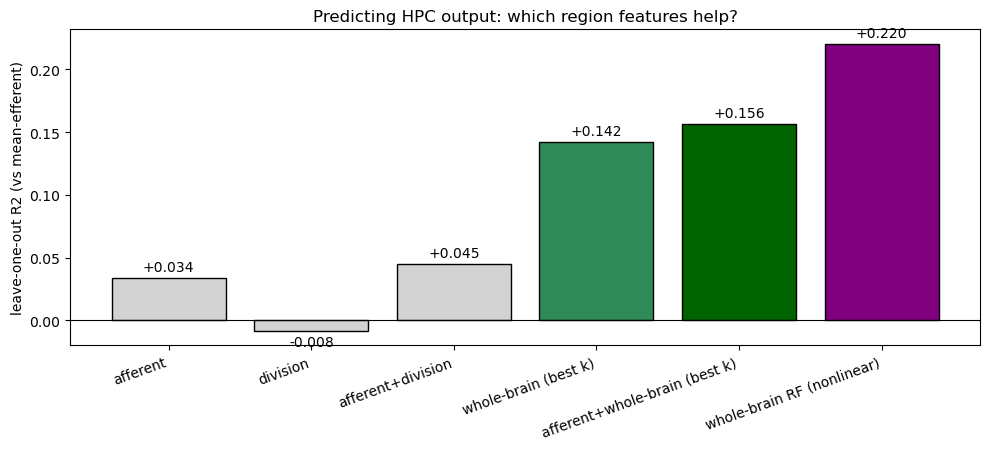

afferent                         0.034
division                        -0.008
afferent+division                0.045
whole-brain (best k)             0.142
afferent+whole-brain (best k)    0.156
whole-brain RF (nonlinear)       0.220


In [5]:
order = ['afferent', 'division', 'afferent+division', 'whole-brain (best k)',
         'afferent+whole-brain (best k)', 'whole-brain RF (nonlinear)']
vals = [results[k] for k in order]
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = ['lightgray', 'lightgray', 'lightgray', 'seagreen', 'darkgreen', 'purple']
bars = ax.bar(range(len(order)), vals, color=colors, edgecolor='k')
ax.bar_label(bars, fmt='%+.3f', padding=3)
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('leave-one-out R2 (vs mean-efferent)')
ax.set_title('Predicting HPC output: which region features help?')
fig.tight_layout(); fig.savefig(OUTDIR / 'predict_efferent_features.png', dpi=120); plt.show()

pd.Series(results).round(3).to_csv(OUTDIR / 'predict_efferent_loo_r2.csv')
print(pd.Series(results).round(3).to_string())

### Takeaway

- **The afferent profile does not predict HPC output** (LOO $R^2 \approx 0$) — confirming Module 2 with
  a different, regularized estimator.
- **Coarse anatomical division doesn't help either** — HPC output is not organized by a 5-way
  region-class label at this granularity.
- **The whole-brain connectivity fingerprint does** — a region's broad connectional identity predicts
  what HPC sends it several-fold better than its afferent input ($R^2 \approx 0.14$ vs $0.03$). Adding
  the afferent profile on top adds little.
- **A nonlinear model does better still** — a random forest on the same whole-brain embedding reaches
  $R^2 \approx 0.22$ (stable across seeds; shuffled-target null $< 0$). So the linear $0.14$ was not a
  ceiling: part of the whole-brain → HPC-output relationship is nonlinear.

**Interpretation.** What the hippocampus sends a region is addressed by **the region's overall place in
the brain's wiring**, not by what that region sends *to* the hippocampus. This reframes the Module 2
null result: HPC output is not unpredictable — it is predictable from *target identity*, just not from
*target input*. The afferent and efferent hippocampal profiles are two largely independent facets of a
region, and the efferent one aligns with the region's global connectivity.

**Caveats.** $R^2 \approx 0.14$–$0.22$ is real but modest — most of the efferent variance is still unexplained
(nonlinearity, spatial/topographic organization we lack coordinates for, or measurement noise). The
whole-brain fingerprint excludes HPC edges, so this is not leakage, but it *is* a rich, high-dimensional
predictor reduced to a few PCs; the effect is stable across $k = 2$–$10$. n = 72 keeps power limited, so
treat the ranking (whole-brain > afferent ≈ division) as the robust result, not the exact $R^2$.